# 📈 Stock Price Forecasting — Predictive Analytics Project

This notebook builds an end-to-end pipeline to **forecast future stock prices** from historical data, and compares two families of models:

- **Regression models** (Linear Regression, Random Forest) using engineered features
- **Time-series models** (ARIMA) using the price series itself

**Pipeline:**
1. Fetch & clean historical data
2. Explore the data (EDA)
3. Feature engineering
4. Train/test split (time-respecting)
5. Train regression models
6. Train an ARIMA time-series model
7. Evaluate & compare all models
8. Visualize predictions vs. actuals

> 💡 Runs in Google Colab. Change `TICKER` below to forecast any stock. If internet/yfinance is unavailable, the notebook automatically falls back to realistic synthetic data so it still runs end-to-end.


## 1. Setup

In [1]:
# Install/upgrade required packages (Colab already has most of these)
!pip install -q yfinance statsmodels scikit-learn pandas numpy matplotlib seaborn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Historical Data

We try to pull real historical prices with `yfinance`. If that fails (no internet, rate limit, invalid ticker), we generate a **synthetic-but-realistic** price series (trend + seasonality + volatility clustering) so the rest of the notebook always runs.


In [3]:
TICKER = "AAPL"      # <-- change this to any ticker, e.g. "MSFT", "TSLA", "GOOGL"
PERIOD = "5y"        # how much history to pull
INTERVAL = "1d"       # daily data

def fetch_real_data(ticker=TICKER, period=PERIOD, interval=INTERVAL):
    import yfinance as yf
    df = yf.download(ticker, period=period, interval=interval, progress=False)
    if df is None or df.empty:
        raise ValueError("No data returned")
    df = df[["Close"]].rename(columns={"Close": "price"})
    df.index.name = "date"
    return df

def generate_synthetic_data(n_days=1260, start_price=150.0, seed=RANDOM_STATE):
    """Realistic-looking synthetic price series: slow drift + yearly seasonality + bounded volatility clustering."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(end=pd.Timestamp.today(), periods=n_days)

    t = np.arange(n_days)
    drift = 0.00025                                          # small daily upward drift
    seasonality = 0.0006 * np.sin(2 * np.pi * t / 252)         # gentle yearly cycle in daily returns

    # Bounded volatility clustering: sigma mean-reverts around a base level instead of compounding
    base_sigma = 0.012
    sigma = np.full(n_days, base_sigma)
    shocks = rng.normal(0, 1, n_days)
    for i in range(1, n_days):
        sigma[i] = np.clip(0.85 * sigma[i-1] + 0.15 * base_sigma + 0.02 * abs(shocks[i-1]) * base_sigma,
                            0.006, 0.035)

    daily_returns = drift + seasonality + sigma * shocks
    daily_returns = np.clip(daily_returns, -0.12, 0.12)        # guard against unrealistic single-day moves

    price = start_price * np.exp(np.cumsum(daily_returns))

    df = pd.DataFrame({"price": price}, index=dates)
    df.index.name = "date"
    return df

try:
    data = fetch_real_data()
    source = "yfinance (real market data)"
except Exception as e:
    print(f"Could not fetch live data ({e}). Falling back to synthetic data.")
    data = generate_synthetic_data()
    source = "synthetic (generated locally)"

print(f"Data source: {source}")
print(f"Rows: {len(data)}  |  Date range: {data.index.min().date()} to {data.index.max().date()}")
data.tail()


Could not fetch live data (No module named 'yfinance'). Falling back to synthetic data.
Data source: synthetic (generated locally)
Rows: 1260  |  Date range: 2021-10-18 to 2026-08-14


,price
date,
2026-08-10,127.890366
2026-08-11,129.239968
2026-08-12,129.200256
2026-08-13,132.210437
2026-08-14,131.392070


## 3. Clean & Preprocess

In [4]:
# Check for missing values / gaps
print("Missing values:\n", data.isna().sum())

# Forward-fill small gaps (e.g. market holidays), then drop any remaining NaNs
data = data.asfreq("B")            # ensure business-day frequency
data["price"] = data["price"].ffill()
data = data.dropna()

print(f"\nRows after cleaning: {len(data)}")
data.describe()


Missing values:
 price    0
dtype: int64

Rows after cleaning: 1260


,price
count,1260.000000
mean,142.822787
std,14.108674
min,110.951811
25%,131.397396
50%,143.359096
75%,153.698589
max,181.841630


### Exploratory Visualization

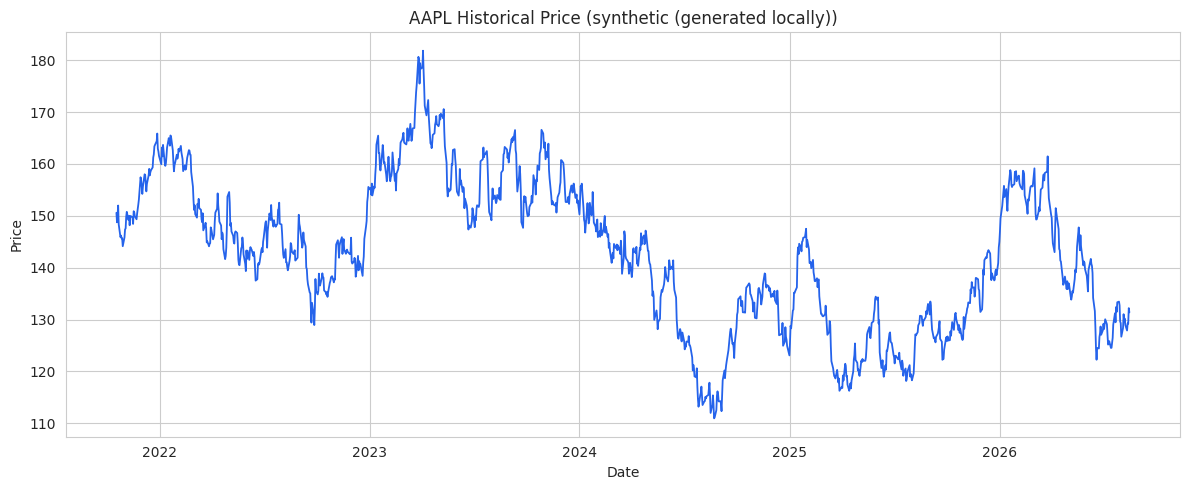

In [5]:
fig, ax = plt.subplots()
ax.plot(data.index, data["price"], color="#2563eb", linewidth=1.3)
ax.set_title(f"{TICKER} Historical Price ({source})")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()


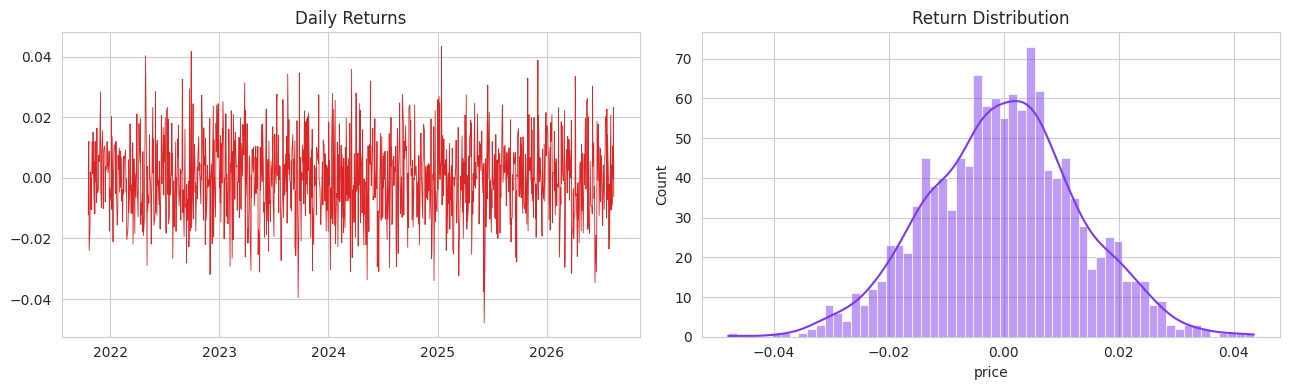

Annualized volatility: 20.82%


In [6]:
# Daily returns distribution (helps sanity-check volatility)
returns = data["price"].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(returns.index, returns, color="#dc2626", linewidth=0.6)
axes[0].set_title("Daily Returns")
sns.histplot(returns, bins=60, kde=True, ax=axes[1], color="#7c3aed")
axes[1].set_title("Return Distribution")
plt.tight_layout()
plt.show()

print(f"Annualized volatility: {returns.std() * np.sqrt(252):.2%}")


## 4. Feature Engineering (for regression models)

Regression models need engineered predictors. We build lag features, moving averages, momentum, and volatility indicators — all using **only past data** (no look-ahead leakage).


In [7]:
def make_features(df, target_col="price"):
    out = pd.DataFrame(index=df.index)
    out["price"] = df[target_col]

    # Lag features
    for lag in [1, 2, 3, 5, 10]:
        out[f"lag_{lag}"] = df[target_col].shift(lag)

    # Moving averages
    out["ma_5"] = df[target_col].shift(1).rolling(5).mean()
    out["ma_10"] = df[target_col].shift(1).rolling(10).mean()
    out["ma_20"] = df[target_col].shift(1).rolling(20).mean()

    # Momentum / volatility
    out["return_1d"] = df[target_col].pct_change(1).shift(1)
    out["return_5d"] = df[target_col].pct_change(5).shift(1)
    out["volatility_10"] = df[target_col].pct_change().shift(1).rolling(10).std()

    # Target: next day's price
    out["target"] = df[target_col].shift(-1)

    return out.dropna()

features_df = make_features(data)
print(f"Feature matrix shape: {features_df.shape}")
features_df.head()


Feature matrix shape: (1239, 13)


,price,lag_1,lag_2,lag_3,lag_5,lag_10,ma_5,ma_10,ma_20,return_1d,return_5d,volatility_10,target
date,,,,,,,,,,,,,
2021-11-15,149.671345,149.949531,149.969093,148.184117,149.172273,145.840906,149.447636,148.859111,148.298047,-0.000130,-0.005463,0.009361,148.448924
2021-11-16,148.448924,149.671345,149.949531,149.969093,149.963167,147.379172,149.547451,149.242155,148.252257,-0.001855,0.003346,0.009089,150.891171
2021-11-17,150.891171,148.448924,149.671345,149.949531,148.184117,147.568736,149.244602,149.349130,148.237323,-0.008167,-0.010097,0.009204,150.673940
2021-11-18,150.673940,150.891171,148.448924,149.671345,149.969093,149.790890,149.786013,149.681374,148.273364,0.016452,0.018268,0.010464,149.930069
2021-11-19,149.930069,150.673940,150.891171,148.448924,149.949531,150.773227,149.926982,149.769679,148.207897,-0.001440,0.004700,0.009479,149.340634


## 5. Train / Test Split

Because this is time-series data, we split **chronologically** (no shuffling) so the model never trains on future information.


In [8]:
FEATURE_COLS = ["lag_1", "lag_2", "lag_3", "lag_5", "lag_10",
                "ma_5", "ma_10", "ma_20", "return_1d", "return_5d", "volatility_10"]

split_idx = int(len(features_df) * 0.85)
train_df = features_df.iloc[:split_idx]
test_df = features_df.iloc[split_idx:]

X_train, y_train = train_df[FEATURE_COLS], train_df["target"]
X_test, y_test = test_df[FEATURE_COLS], test_df["target"]

print(f"Train size: {len(train_df)}  |  Test size: {len(test_df)}")
print(f"Test period: {test_df.index.min().date()} to {test_df.index.max().date()}")


Train size: 1053  |  Test size: 186
Test period: 2025-11-27 to 2026-08-13


## 6. Model 1 & 2 — Regression Approaches

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_pred = lin_reg.predict(X_test)

rf_reg = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train)
rf_pred = rf_reg.predict(X_test)

print("Regression models trained.")


Regression models trained.


## 7. Model 3 — ARIMA (Time-Series Approach)

ARIMA models the price series directly using its own past values and past errors. We first check stationarity with an Augmented Dickey-Fuller test, then fit the model.


In [10]:
def adf_test(series, label=""):
    result = adfuller(series.dropna())
    print(f"ADF test {label}: statistic={result[0]:.3f}, p-value={result[1]:.4f}")
    print("  -> Stationary" if result[1] < 0.05 else "  -> Non-stationary (differencing needed)")

price_train = data["price"].iloc[:split_idx + 10]   # align roughly with regression train window
price_test = data["price"].iloc[split_idx + 10:]

adf_test(price_train, "on raw price")
adf_test(price_train.diff(), "on 1st difference")


ADF test on raw price: statistic=-2.230, p-value=0.1955
  -> Non-stationary (differencing needed)
ADF test on 1st difference: statistic=-30.077, p-value=0.0000
  -> Stationary


In [11]:
# ARIMA(p,d,q): d=1 handles the trend (non-stationarity) found above.
# A small, robust order is used here; for production use, grid-search or auto_arima to tune (p,d,q).
arima_model = ARIMA(price_train, order=(5, 1, 0))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(price_test))
arima_forecast.index = price_test.index

print(arima_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                 1063
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2164.664
Date:                Fri, 14 Aug 2026   AIC                           4341.328
Time:                        21:09:01   BIC                           4371.135
Sample:                    10-18-2021   HQIC                          4352.623
                         - 11-12-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0807      0.030      2.709      0.007       0.022       0.139
ar.L2         -0.0255      0.028     -0.898      0.369      -0.081       0.030
ar.L3          0.0014      0.030      0.046      0.9

## 8. Evaluate & Compare All Models

In [12]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "R²": r2}

results = [
    evaluate(y_test, lin_pred, "Linear Regression"),
    evaluate(y_test, rf_pred, "Random Forest"),
    evaluate(price_test, arima_forecast, "ARIMA"),
]

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


,RMSE,MAE,MAPE (%),R²
Model,,,,
Linear Regression,2.990,2.347,1.651,0.922
Random Forest,3.354,2.638,1.860,0.902
ARIMA,12.772,10.320,6.987,-0.477


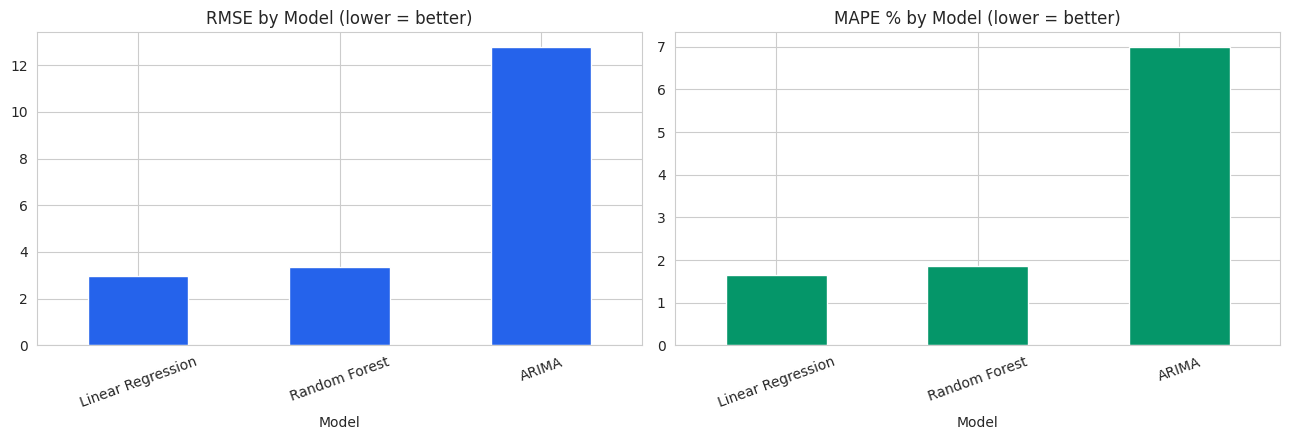

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
results_df["RMSE"].plot(kind="bar", ax=axes[0], color="#2563eb")
axes[0].set_title("RMSE by Model (lower = better)")
axes[0].tick_params(axis="x", rotation=20)

results_df["MAPE (%)"].plot(kind="bar", ax=axes[1], color="#059669")
axes[1].set_title("MAPE % by Model (lower = better)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 9. Visualize Predictions vs. Actuals

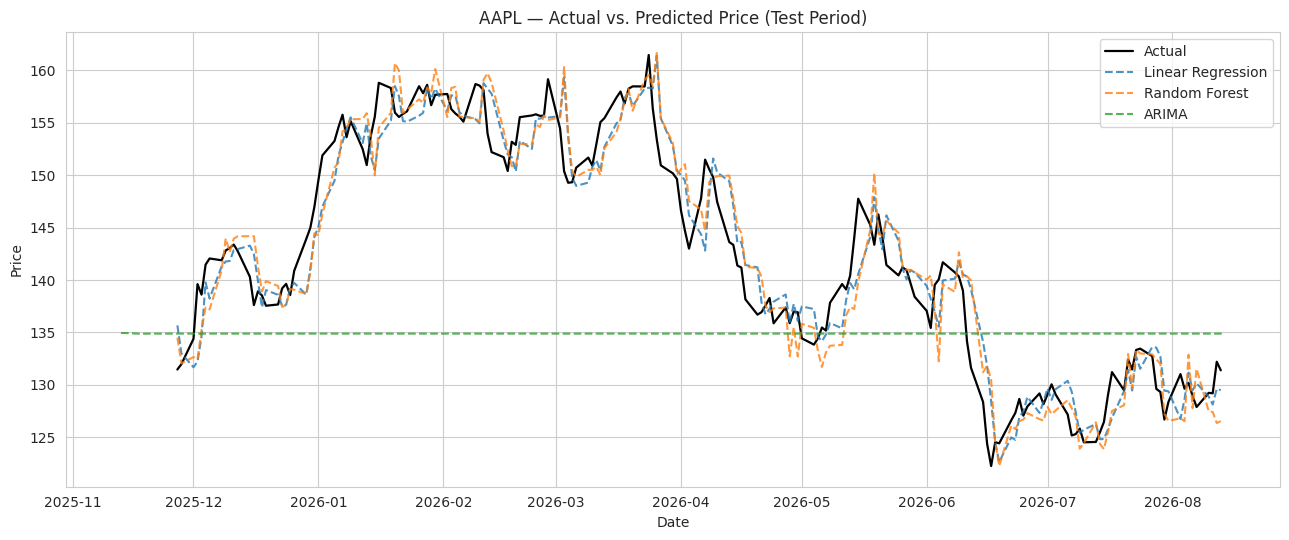

In [14]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(y_test.index, y_test, label="Actual", color="black", linewidth=1.6)
ax.plot(y_test.index, lin_pred, label="Linear Regression", linestyle="--", alpha=0.8)
ax.plot(y_test.index, rf_pred, label="Random Forest", linestyle="--", alpha=0.8)
ax.plot(arima_forecast.index, arima_forecast, label="ARIMA", linestyle="--", alpha=0.8)
ax.set_title(f"{TICKER} — Actual vs. Predicted Price (Test Period)")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()


Best model by RMSE: Linear Regression


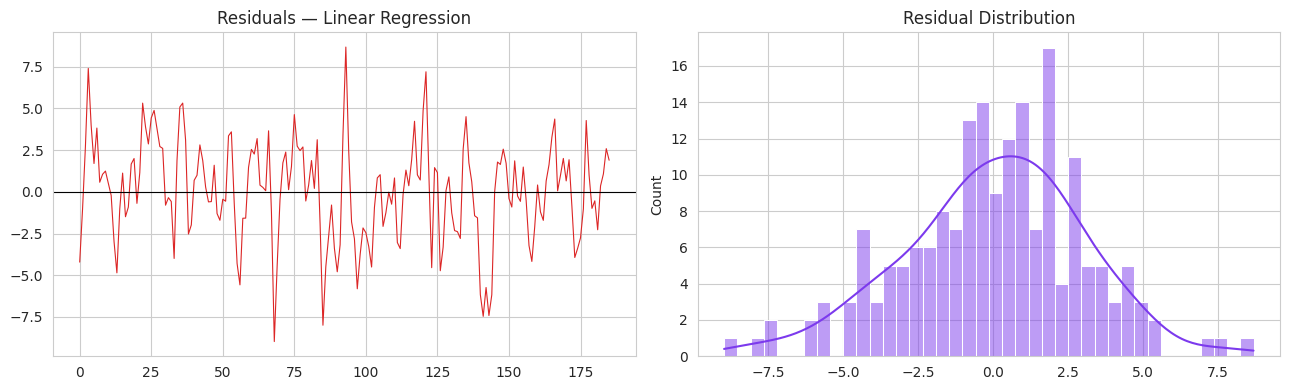

In [15]:
# Residual analysis for the best model (by RMSE)
best_model = results_df["RMSE"].idxmin()
print(f"Best model by RMSE: {best_model}")

pred_map = {"Linear Regression": lin_pred, "Random Forest": rf_pred, "ARIMA": arima_forecast.values}
true_map = {"Linear Regression": y_test, "Random Forest": y_test, "ARIMA": price_test}

resid = np.array(true_map[best_model]) - np.array(pred_map[best_model])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(resid, color="#dc2626", linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Residuals — {best_model}")
sns.histplot(resid, bins=40, kde=True, ax=axes[1], color="#7c3aed")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()


## 10. Forecast Beyond the Available Data

Using the best-performing model, forecast the next N business days into the future.


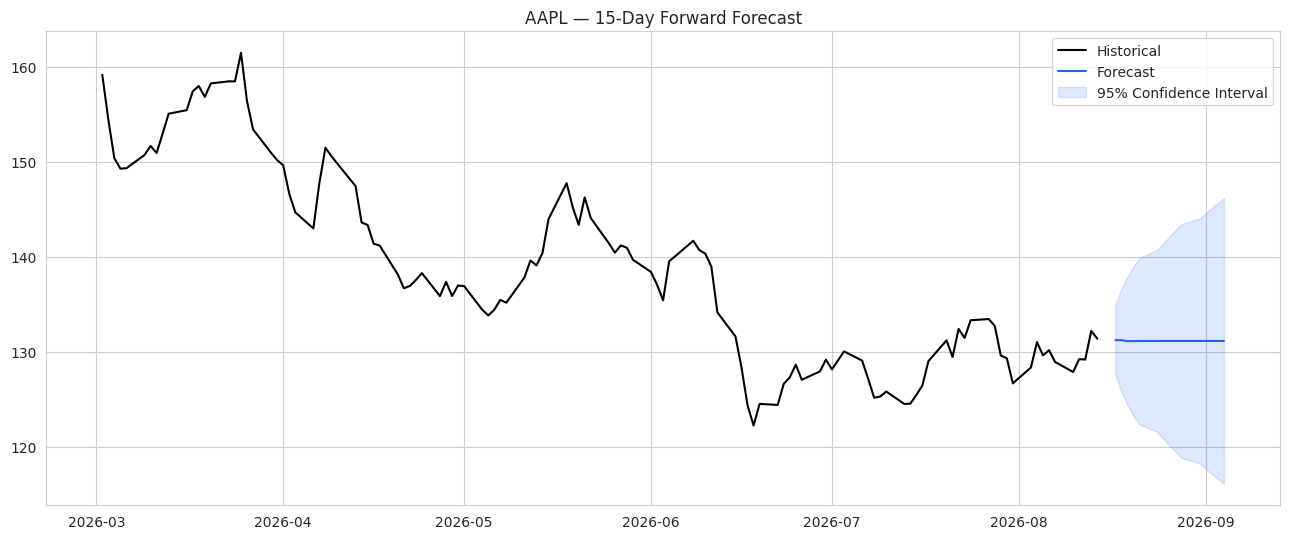

,forecast_price
2026-08-17,131.247788
2026-08-18,131.232317
2026-08-19,131.137076
2026-08-20,131.140056
2026-08-21,131.149595
2026-08-24,131.151776
2026-08-25,131.155016
2026-08-26,131.155655
2026-08-27,131.155370
2026-08-28,131.155219


In [16]:
N_FUTURE_DAYS = 15

# Refit ARIMA (often the most natural for pure future forecasting) on the FULL series
final_arima = ARIMA(data["price"], order=(5, 1, 0)).fit()
future_forecast = final_arima.get_forecast(steps=N_FUTURE_DAYS)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int(alpha=0.05)

future_dates = pd.bdate_range(start=data.index[-1] + pd.Timedelta(days=1), periods=N_FUTURE_DAYS)
future_mean.index = future_dates
future_ci.index = future_dates

fig, ax = plt.subplots(figsize=(13, 5.5))
recent = data["price"].iloc[-120:]
ax.plot(recent.index, recent, label="Historical", color="black")
ax.plot(future_mean.index, future_mean, label="Forecast", color="#2563eb")
ax.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                 color="#2563eb", alpha=0.15, label="95% Confidence Interval")
ax.set_title(f"{TICKER} — {N_FUTURE_DAYS}-Day Forward Forecast")
ax.legend()
plt.tight_layout()
plt.show()

future_mean.rename("forecast_price").to_frame()


## 11. Summary & Next Steps

**What this notebook covered:**
- Fetching and cleaning historical price data (with a synthetic-data fallback)
- Exploratory analysis of price and return behavior
- Leak-free feature engineering for regression models
- Three forecasting approaches: Linear Regression, Random Forest, ARIMA
- Quantitative evaluation (RMSE, MAE, MAPE, R²) and visual comparison
- A genuine out-of-sample forecast with confidence intervals

**Ways to extend this:**
- Tune ARIMA order with `pmdarima.auto_arima`, or try `SARIMAX` for seasonality
- Add exogenous features (volume, macro indicators, sentiment) via `SARIMAX` or gradient boosting (XGBoost/LightGBM)
- Try `Prophet` or `NeuralProphet` for automatic seasonality/holiday handling
- Backtest with walk-forward (rolling-origin) validation instead of a single train/test split
- Remember: stock prices are notoriously close to a random walk — treat short-horizon accuracy claims with healthy skepticism, and never treat this notebook as financial advice.
